In [1]:

import numpy as np
import scipy.stats
import sys
import seaborn as sns

from io import UnsupportedOperation
import pickle as pkl

import csv
import matplotlib.pyplot as plt

# Add shared location for auxillary functions
sys.path.insert(1, './../../AuxillaryFunctions')

# import personal Functions
# from GenerateClassDataFuncs import GenerateEvalData_ClemCafe
# from GenerateClassDataFuncs import GenerateEvalData_OREBA
from GenerateClassDataFuncs import GenerateTallyCounts

from EvaluationMethodFuncs import TimePoint2Window
from EvaluationMethodFuncs import Window2TimePoint
from EvaluationMethodFuncs import DongEval_PtVsPt
from EvaluationMethodFuncs import KyritEval_PtVsWindow
from EvaluationMethodFuncs import Duration_WindowVsWindow
from EvaluationMethodFuncs import PrintStats


print("Finished importing libraries.") 

Finished importing libraries.


In [2]:
def readPredCSV(fileName):
	
	with open(fileName, mode ='r') as fp:
		csvFile = csv.reader(fp)

		Predictions = []
		Timesteps = []

		for row in csvFile:
			Predictions.append(float(row[0]))
			Timesteps.append(float(row[1]))
		# end

		# print(len(Predictions))
	# end of open fp
	
	return [Predictions, Timesteps]

# end of def()



def readGtCSV(fileName):
	
	with open(fileName, mode ='r') as fp:
		csvFile = csv.reader(fp)

		GT_events = []

		for row in csvFile:
			GT_events.append(float(row[0]))
		# end

		# print(len(GT_events))
	# end of open fp
	
	return GT_events
	
# end of def()


print("Finished defining local functions.")


Finished defining local functions.


In [3]:
def MakeHeatMap(Predicitions, Counts, Intervals, MaxCount = -1):
	'''
	INPUTS:
		Intervals = 1D array of the start points for each bucket
		Predictions = 1D array of the Predictions from the model
		Counts = 1D array corresponding GT counts for each Prediction
	OUTPUT:
		HeatMap = 2D array with Counts as the Columns and 
	'''
	
	if MaxCount == -1: # if not limiting max count
		MaxCount = max(Counts)
	# end of if
	
	HeatMap = np.zeros([MaxCount+1,len(Intervals)-1])
	
	for i in range(MaxCount+1): # Main Interval
		for j in range(len(Intervals)-1):
			HeatMap[i,j] = np.sum(np.logical_and(np.logical_and(Intervals[j] <= Predicitions, Predicitions < Intervals[j+1]), Counts == i))
		# end of for j
	# end of for i
	
	#### ALTERNATIVE METHOD
	# ## Loop over all predicitons and add somewhere
	# HeatMap2 = np.zeros([len(Intervals)-1,max(FlatCountsOHO)+1])
	# setPred = 0
	# for i in range(len(FlatPredsOHO)):
	# 	for j in range(len(Intervals)-1):
	# 		if (Intervals[j] <= FlatPredsOHO[i]) and (FlatPredsOHO[i] < Intervals[j+1]):
	# 			HeatMap2[j,FlatCountsOHO[i]] += 1
	# 			setPred += 1
	# 		# end of if
	# 	# end of for j
	# # end of for i
	
# 	# Print HeatMaps
	
	return HeatMap
# end of def MakeHeatMap()

def PrintHeatMap(HeatMap):
	TotalCount = 0
	nrows, ncols = np.shape(HeatMap)
	for i in range(nrows):
		# for j in range(max(FlatCountsOHO)+1): # FULL SPECTRUM
		for j in range(ncols): # Main Interval
			print("{:8d}  ".format(int(HeatMap[i,j])), end='')
			TotalCount += int(HeatMap[i,j])
		# end of for j
		print("")
	# end of for i
	print("TotalCount = {}".format(TotalCount))
# end of def PrintHeatMap


def NormalizeHeatMap(HeatMap, alongRows = False):
	nrows, ncols = np.shape(HeatMap)
	HeatMapNorm = np.zeros([nrows, ncols])
	
	if alongRows == True:
		for i in range(nrows):
			currSum = np.sum(HeatMap[i,:])
			HeatMapNorm[i,:] = 100*HeatMap[i,:]/currSum
		# end of for i
	else: # if normalizing each column
		for i in range(ncols):
			currSum = np.sum(HeatMap[:,i])
			HeatMapNorm[:,i] = 100*HeatMap[:,i]/currSum
		# end of for i
	# end of axis switch
	
	return HeatMapNorm
# end of def NormalizeHeatMap()

def AddSpacerRows(HeatMap, numSpacers = 1):
	'''
	Adds spacer rows filled with zeros between rows of the given 2D HeatMap
	Inputs: 
		HeatMap: 2D numpy array - given heatmap data
		numSpacers: Int - number of rows to insert between each row of the HeatMap
	Outputs:
		NewHeatMap: 2D numpy array
	'''
	
	# compute the new size # subtract 1 from spacers since the last row does not have one after it
	totalNewRows = np.shape(HeatMap)[0] + (np.shape(HeatMap)[0] - 1) * numSpacers 
	NewHeatMap = np.zeros([totalNewRows, np.shape(HeatMap)[1]]) # np.zeros(len(Intervals) - 1)
	for i in range(np.shape(HeatMap)[0]):
		NewHeatMap[i*(numSpacers+1),:] = HeatMap[i,:]
	# end of for i
	
	return NewHeatMap
# end of def AddSpacerRows



print("Finished defining local HeatMap functions.")


Finished defining local HeatMap functions.


In [4]:
# Loop over all ClemMeals

DndClemsonPredFileList =  [line[:-1] for line in open("./PredFilenames/Files_DndClem_CGv3_Preds.txt",'r')]
DomClemsonPredFileList =  [line[:-1] for line in open("./PredFilenames/Files_DomClem_CGv3_Preds.txt",'r')]
DndOHOPredFileList =  [line[:-1] for line in open("./PredFilenames/Files_DndOHO_CGv3_Preds.txt",'r')]
DomOHOPredFileList =  [line[:-1] for line in open("./PredFilenames/Files_DomOHO_CGv3_Preds.txt",'r')]
THOPredFileList =  [line[:-1] for line in open("./PredFilenames/Files_THO_CGv3_Preds.txt",'r')]


DndClemsonGTFileList =  [line[:-1] for line in open("./PredFilenames/Files_DndClem_CGv3_GTs.txt",'r')]
DomClemsonGTFileList =  [line[:-1] for line in open("./PredFilenames/Files_DomClem_CGv3_GTs.txt",'r')]
DndOHOGTFileList =  [line[:-1] for line in open("./PredFilenames/Files_DndOHO_CGv3_GTs.txt",'r')]
DomOHOGTFileList =  [line[:-1] for line in open("./PredFilenames/Files_DomOHO_CGv3_GTs.txt",'r')]
THOGTFileList =  [line[:-1] for line in open("./PredFilenames/Files_THO_CGv3_GTs.txt",'r')]

print("Finished Defining File Lists")

Finished Defining File Lists


In [5]:
# Define processing function to save space 

def ProcessFiles(preds_file_list, gt_file_list, print_percent = 0.05):
    """
    Function: ProcessFiles()

    Args:
        preds_file_list
        gt_file_list
        print_percent - defaults to 5%, value should be between 0 and 1
    """
    
    ### OHO STATS ###
    
    AllDiffs = []
    AllPreds = []
    AllCounts = []
    
    printInterval = round(len(preds_file_list) * print_percent)
    
    for currFileIdx in range(len(preds_file_list)):
    
        [preds, timesteps] = readPredCSV("./"+preds_file_list[currFileIdx])
        gt_times = np.array(readGtCSV("./"+gt_file_list[currFileIdx]))
    
        CUT_sec = 15 # 15 second models
        Counts = GenerateTallyCounts(gt_times, timesteps, CUT_sec)
    
        currDiffs = []
        for i in range(len(preds)):
            currDiffs.append(preds[i] - Counts[i])
        # end of j
    
        AllDiffs.append(currDiffs)
        AllPreds.append(preds)
        AllCounts.append(Counts)
    
        if currFileIdx % printInterval == 0:
            print("Through File {} of {}".format(currFileIdx, len(preds_file_list)))
        # end
    
    # end of for i
    
    FlatPreds = np.array(np.concatenate(AllPreds).flat)
    FlatCounts = np.array(np.concatenate(AllCounts).flat)
    FlatDiffs = np.array(np.concatenate(AllDiffs).flat)
    
    print("\nMean   = {}".format(np.mean(FlatDiffs)))
    print("Median = {}".format(np.median(FlatDiffs)))
    print("StdDev = {}".format(np.std(FlatDiffs)))
    
    
    slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(FlatPreds,FlatCounts)
    
    print("R = {}".format(r_value))
    print("R^2 = {}".format(r_value**2))
    print("P = {}\n\n".format(p_value))
    
    return(FlatPreds, FlatCounts, FlatDiffs)

# end


print("Finished defining prcoessing function.")


Finished defining prcoessing function.


In [7]:
FlatPredsDndOHO, FlatCountsDndOHO, FlatDiffsDndOHO = ProcessFiles(DndOHOPredFileList, DndOHOGTFileList)


Through File 0 of 600
Through File 30 of 600
Through File 60 of 600
Through File 90 of 600
Through File 120 of 600
Through File 150 of 600
Through File 180 of 600
Through File 210 of 600
Through File 240 of 600
Through File 270 of 600
Through File 300 of 600
Through File 330 of 600
Through File 360 of 600
Through File 390 of 600
Through File 420 of 600
Through File 450 of 600
Through File 480 of 600
Through File 510 of 600
Through File 540 of 600
Through File 570 of 600

Mean   = -0.05250053627886503
Median = 0.007899999999999796
StdDev = 0.5836240170171598
R = 0.7063666580231227
R^2 = 0.4989538555667552
P = 0.0




In [8]:
FlatPredsDomOHO, FlatCountsDomOHO, FlatDiffsDomOHO = ProcessFiles(DomOHOPredFileList, DomOHOGTFileList)


Through File 0 of 600
Through File 30 of 600
Through File 60 of 600
Through File 90 of 600
Through File 120 of 600
Through File 150 of 600
Through File 180 of 600
Through File 210 of 600
Through File 240 of 600
Through File 270 of 600
Through File 300 of 600
Through File 330 of 600
Through File 360 of 600
Through File 390 of 600
Through File 420 of 600
Through File 450 of 600
Through File 480 of 600
Through File 510 of 600
Through File 540 of 600
Through File 570 of 600

Mean   = -0.02529386207783867
Median = 0.0026
StdDev = 0.4530903573332962
R = 0.8405453258311631
R^2 = 0.7065164447766162
P = 0.0




In [9]:
FlatPredsDndClem, FlatCountsDndClem, FlatDiffsDndClem = ProcessFiles(DndClemsonPredFileList, DndClemsonGTFileList)


Through File 0 of 2928
Through File 146 of 2928
Through File 292 of 2928
Through File 438 of 2928
Through File 584 of 2928
Through File 730 of 2928
Through File 876 of 2928
Through File 1022 of 2928
Through File 1168 of 2928
Through File 1314 of 2928
Through File 1460 of 2928
Through File 1606 of 2928
Through File 1752 of 2928
Through File 1898 of 2928
Through File 2044 of 2928
Through File 2190 of 2928
Through File 2336 of 2928
Through File 2482 of 2928
Through File 2628 of 2928
Through File 2774 of 2928
Through File 2920 of 2928

Mean   = -0.059709961095407466
Median = 0.011400000000000077
StdDev = 0.5956266558959704
R = 0.7125897184049236
R^2 = 0.5077841067764083
P = 0.0




In [6]:
FlatPredsDomClem, FlatCountsDomClem, FlatDiffsDomClem = ProcessFiles(DomClemsonPredFileList, DomClemsonGTFileList)


Through File 0 of 2928
Through File 146 of 2928
Through File 292 of 2928
Through File 438 of 2928
Through File 584 of 2928
Through File 730 of 2928
Through File 876 of 2928
Through File 1022 of 2928
Through File 1168 of 2928
Through File 1314 of 2928
Through File 1460 of 2928
Through File 1606 of 2928
Through File 1752 of 2928
Through File 1898 of 2928
Through File 2044 of 2928
Through File 2190 of 2928
Through File 2336 of 2928
Through File 2482 of 2928
Through File 2628 of 2928
Through File 2774 of 2928
Through File 2920 of 2928

Mean   = -0.030310613151244517
Median = 0.0035000000000000586
StdDev = 0.49828978057757906
R = 0.8102858294439834
R^2 = 0.6565631253977242
P = 0.0




In [10]:
FlatPredsTHO, FlatCountsTHO, FlatDiffsTHO = ProcessFiles(THOPredFileList, THOGTFileList)


Through File 0 of 600
Through File 30 of 600
Through File 60 of 600
Through File 90 of 600
Through File 120 of 600
Through File 150 of 600
Through File 180 of 600
Through File 210 of 600
Through File 240 of 600
Through File 270 of 600
Through File 300 of 600
Through File 330 of 600
Through File 360 of 600
Through File 390 of 600
Through File 420 of 600
Through File 450 of 600
Through File 480 of 600
Through File 510 of 600
Through File 540 of 600
Through File 570 of 600

Mean   = -0.21192977176416014
Median = -0.006299999999999972
StdDev = 0.6379200670785707
R = 0.6811035468635738
R^2 = 0.4639020415501404
P = 0.0




In [11]:
FlatPredsTHO = FlatPredsDndTHO
FlatCountsTHO = FlatCountsDndTHO
FlatDiffsTHO = FlatDiffsDndTHO

In [12]:
### Pre-Processing for Violin Plots

MAX_COUNT = 3

TrimmedPredsDndOHO = FlatPredsDndOHO[np.logical_and(FlatCountsDndOHO<=MAX_COUNT, FlatPredsDndOHO<=MAX_COUNT)]
TrimmedCountsDndOHO = FlatCountsDndOHO[np.logical_and(FlatCountsDndOHO<=MAX_COUNT, FlatPredsDndOHO<=MAX_COUNT)]

TrimmedPredsDomOHO = FlatPredsDomOHO[np.logical_and(FlatCountsDomOHO<=MAX_COUNT, FlatPredsDomOHO<=MAX_COUNT)]
TrimmedCountsDomOHO = FlatCountsDomOHO[np.logical_and(FlatCountsDomOHO<=MAX_COUNT, FlatPredsDomOHO<=MAX_COUNT)]


TrimmedPredsDndClem = FlatPredsDndClem[np.logical_and(FlatCountsDndClem<=MAX_COUNT, FlatPredsDndClem<=MAX_COUNT)]
TrimmedCountsDndClem = FlatCountsDndClem[np.logical_and(FlatCountsDndClem<=MAX_COUNT, FlatPredsDndClem<=MAX_COUNT)]

TrimmedPredsDomClem = FlatPredsDomClem[np.logical_and(FlatCountsDomClem<=MAX_COUNT, FlatPredsDomClem<=MAX_COUNT)]
TrimmedCountsDomClem = FlatCountsDomClem[np.logical_and(FlatCountsDomClem<=MAX_COUNT, FlatPredsDomClem<=MAX_COUNT)]


TrimmedPredsTHO = FlatPredsTHO[np.logical_and(FlatCountsTHO<=MAX_COUNT, FlatPredsTHO<=MAX_COUNT)]
TrimmedCountsTHO = FlatCountsTHO[np.logical_and(FlatCountsTHO<=MAX_COUNT, FlatPredsTHO<=MAX_COUNT)]

print("Finished")


Finished


/local_scratch/slurm.13462022/ipykernel_1215187/853544328.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x=TrimmedCountsDomClem, y=TrimmedPredsDomClem,orient='v',palette="tab10",density_norm='width',inner='quart')


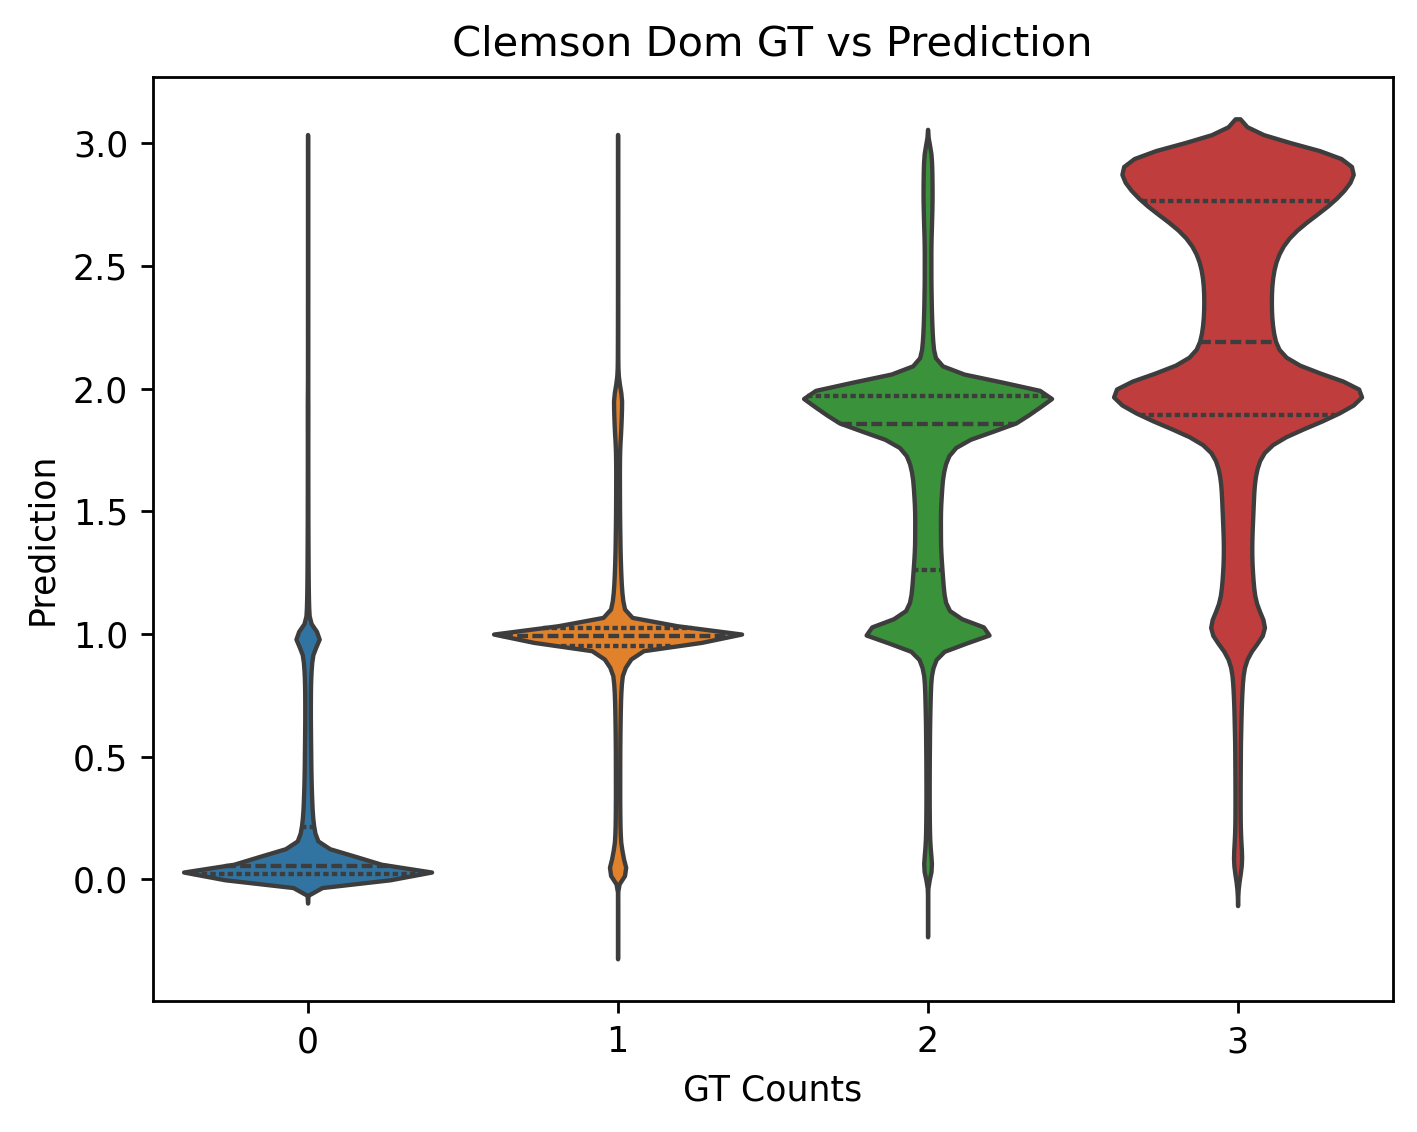

In [13]:
### Generation of Clemson Violin Plot

plt.figure('w', dpi=250)

sns.violinplot(x=TrimmedCountsDomClem, y=TrimmedPredsDomClem,orient='v',palette="tab10",density_norm='width',inner='quart')
# sns.violinplot(x=TrimmedCountsClem, y=TrimmedPredsClem,orient='v',inner='quart')
plt.title("Clemson Dom GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_DomClem_CGv3_v2.pdf", bbox_inches='tight')

In [ ]:
### Generation of Clemson Violin Plot

plt.figure('w', dpi=250)

sns.violinplot(x=TrimmedCountsDomOHO, y=TrimmedPredsDomOHO,orient='v',palette="tab10",density_norm='width',inner='quart')
# sns.violinplot(x=TrimmedCountsClem, y=TrimmedPredsClem,orient='v',inner='quart')
plt.title("OHO Dom GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_DomOHO_CGv3_v2.pdf", bbox_inches='tight')

In [ ]:
### Generation of Clemson Violin Plot

plt.figure('w', dpi=250)

sns.violinplot(x=TrimmedCountsClem, y=TrimmedPredsClem,orient='v',density_norm='width',inner='quart')
# sns.violinplot(x=TrimmedCountsClem, y=TrimmedPredsClem,orient='v',inner='quart')
plt.title("Clemson GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_DndClem_CGv3_v2.pdf", bbox_inches='tight')

In [ ]:
### Generation of THO Violin Plot

plt.figure('w', dpi=250)

sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v',density_norm='width',inner='quart')
# sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v', hue="alive", density_norm='width', inner='quart')

# sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v',inner='quart')
plt.title("THO GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_THO_CGv3_v2.pdf", bbox_inches='tight')

In [ ]:
### Generation of OHO Violin Plot

plt.figure('w', dpi=250)

sns.violinplot(x=TrimmedCountsOHO, y=TrimmedPredsOHO,orient='v',density_norm='width',inner='quart')
plt.title("OHO GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_DndOHO_CGv3_v2.pdf", bbox_inches='tight')

In [ ]:
sns.__version__

In [ ]:
### Generation of THO Violin Plot

plt.figure('w', dpi=50)

# sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v',density_norm='width',inner='quart')
sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v', palette="tab10", density_norm='width', inner='quart')

# sns.violinplot(x=TrimmedCountsTHO, y=TrimmedPredsTHO,orient='v',inner='quart')
plt.title("THO GT vs Prediction")
plt.xlabel("GT Counts")
plt.ylabel("Prediction")

plt.savefig("Figures/PredVsGT_Violin_THO_CGv3_v2.pdf")

In [ ]:
### GENERATE FIGURES as Scatter Plots

SUBSAMPLE_RATE=800

plt.figure(dpi=400)
plt.plot(FlatPredsOHO[0:-1:SUBSAMPLE_RATE],FlatCountsOHO[0:-1:SUBSAMPLE_RATE],'k.', markersize=2)
plt.xlabel("Predicitions")
plt.ylabel("GT Counts")
plt.title("OHO Preds vs Counts")
# plt.savefig("Figures/PredVsCnt_OHO.jpg")

print("finished Making OHO Figure...")

# plt.figure(dpi=400)
# plt.plot(FlatPredsTHO[0:-1:SUBSAMPLE_RATE],FlatCountsTHO[0:-1:SUBSAMPLE_RATE],'k.', markersize=2)
# plt.xlabel("Predicitions")
# plt.ylabel("GT Counts")
# plt.title("THO Preds vs Counts")
# # plt.savefig("Figures/PredVsCnt_THO.jpg")

# print("finished Making THO Figure...")


# plt.figure(dpi=400)
# plt.plot(FlatPredsClem[0:-1:SUBSAMPLE_RATE],FlatCountsClem[0:-1:SUBSAMPLE_RATE],'k.', markersize=2)
# plt.xlabel("Predicitions")
# plt.ylabel("GT Counts")
# plt.title("Clem Preds vs Counts")
# # plt.savefig("Figures/PredVsCnt_Clem.jpg")

# print("finished Making Clem Figure.")


In [ ]:
### GENREATE FIGURES as Heat Map

GENERATE_OHO_FIGURE = 1
GENERATE_THO_FIGURE = 1
GENERATE_CLEM_FIGURE = 1



MAX_COUNT = 5
IntervalStep = 1.0
Intervals = np.arange(-IntervalStep+IntervalStep/2, MAX_COUNT+IntervalStep, IntervalStep) # FULL SPECTRUM


if GENERATE_OHO_FIGURE == 1:
	TotalPairs = len(FlatPredsOHO)
	
	HeatMapOHO = MakeHeatMap(FlatPredsOHO, FlatCountsOHO, Intervals, MaxCount = MAX_COUNT)
	PrintHeatMap(HeatMapOHO)
	
	# print(HeatMap)
	print("Finished with OHO\n")
	
if GENERATE_THO_FIGURE == 1:
	HeatMapTHO = MakeHeatMap(FlatPredsTHO, FlatCountsTHO, Intervals, MaxCount = MAX_COUNT)
	PrintHeatMap(HeatMapTHO)
	print("Finished with THO\n")

if GENERATE_CLEM_FIGURE == 1:
	HeatMapClem = MakeHeatMap(FlatPredsClem, FlatCountsClem, Intervals, MaxCount = MAX_COUNT)
	PrintHeatMap(HeatMapClem)
	print("Finished with Clemson\n")
	
# end if


In [ ]:
if GENERATE_OHO_FIGURE == 1:
	plt.figure('w', dpi=200)
	PlottingHeatMap = NormalizeHeatMap(HeatMapOHO,1)
	# PlottingHeatMap = AddSpacerRows(PlottingHeatMap)
	PlottingHeatMap = np.transpose(PlottingHeatMap)
	PlottingHeatMap = np.flip(PlottingHeatMap,0)
	plt.imshow(PlottingHeatMap, cmap='inferno')
	# plt.imshow(HeatMapClem, cmap='viridis')
	plt.colorbar()

	xticks = []
	yticks = []
	for i in range(len(Intervals)-1):
		yticks.append("{:0.1f}-{:0.1f}".format(Intervals[i], Intervals[i+1]))
	# end of for i
	yticks.reverse()
	for i in range(MAX_COUNT+1):
		xticks.append("{:0d}".format(int(i)))
		# xticks.append("")
	# end of for i
	# xticks.pop() # remove last extra blank
	
	plt.xticks(range(len(xticks)), xticks)
	# plt.xticks(range(len(xticks)), xticks, rotation = 60)
	plt.yticks(range(len(yticks)), yticks)
	
	plt.title("OHO Predictions vs GT HeatMap")
	# plt.xlabel("Predicition Ranges")
	plt.ylabel("Predicition Ranges [% of GT class]")
	plt.xlabel("GT Target")
	
	# plt.savefig("Figures/PredVsGtHeatMap_v4_OHO_05.pdf")
	# plt.savefig("Figures/PredictionsVsGtHeatMapOHO_step05_normalized.pdf")
	
# end of if GENERATE_FIGURES
print("Finished Making Figure")


In [ ]:
	
if GENERATE_THO_FIGURE == 1:
	plt.figure('w',dpi=200)
	PlottingHeatMap = NormalizeHeatMap(HeatMapTHO)
	PlottingHeatMap = AddSpacerRows(PlottingHeatMap)
	PlottingHeatMap = np.transpose(PlottingHeatMap)
	PlottingHeatMap = np.flip(PlottingHeatMap,0)
	plt.imshow(PlottingHeatMap, cmap='inferno')
	# plt.imshow(HeatMapClem, cmap='viridis')
	plt.colorbar()

	xticks = []
	yticks = []
	for i in range(len(Intervals)-1):
		yticks.append("{:0.1f}-{:0.1f}".format(Intervals[i], Intervals[i+1]))
	# end of for i
	yticks.reverse()
	for i in range(MAX_COUNT+1):
		xticks.append("{:0d}".format(int(i)))
		xticks.append("")
	# end of for i
	xticks.pop() # remove last extra blank
	
	plt.xticks(range(len(xticks)), xticks)
	# plt.xticks(range(len(xticks)), xticks, rotation = 60)
	plt.yticks(range(len(yticks)), yticks)

	plt.title("THO Predictions vs GT HeatMap")
	plt.ylabel("Predicition Ranges [% of GT class]")
	# plt.xlabel("Predicition Ranges")
	plt.xlabel("GT Target")
	
	plt.savefig("Figures/PredVsGtHeatMap_v4_THO_05.pdf")
	# plt.savefig("Figures/PredictionsVsGtHeatMapTHO_step10.pdf")
	
# end of if GENERATE_FIGURES
print("Finished Making Figure")


In [ ]:
if GENERATE_CLEM_FIGURE == 1:
	
	plt.figure('w', dpi=200)
	PlottingHeatMap = NormalizeHeatMap(HeatMapClem)
	PlottingHeatMap = AddSpacerRows(PlottingHeatMap)
	PlottingHeatMap = np.transpose(PlottingHeatMap)
	PlottingHeatMap = np.flip(PlottingHeatMap,0)
	plt.imshow(PlottingHeatMap, cmap='inferno')
	# plt.imshow(HeatMapClem, cmap='viridis')
	plt.colorbar()

	xticks = []
	yticks = []
	for i in range(len(Intervals)-1):
		yticks.append("{:0.1f}-{:0.1f}".format(Intervals[i], Intervals[i+1]))
	# end of for i
	yticks.reverse()
	for i in range(MAX_COUNT+1):
		xticks.append("{:0d}".format(int(i)))
		xticks.append("")
	# end of for i
	xticks.pop() # remove last extra blank
	
	plt.xticks(range(len(xticks)), xticks)
	# plt.xticks(range(len(xticks)), xticks, rotation = 60)
	plt.yticks(range(len(yticks)), yticks)

	plt.title("Clem Predictions vs GT HeatMap")
	plt.ylabel("Predicition Ranges [% of GT class]")
	# plt.xlabel("Predicition Ranges")
	plt.xlabel("GT Target")
	
	plt.savefig("Figures/PredVsGtHeatMap_v4_Clem_05.pdf")
	# plt.savefig("Figures/PredictionsVsGtHeatMapClem_step05_normalized.pdf")
	# plt.savefig("Figures/PredictionsVsGtHeatMapClem_step10.pdf")
	
# end of if GENERATE_FIGURES
print("Finished Making Figure")

In [ ]:
print("Original")
PrintHeatMap(PlottingHeatMap)


print("\n\nFlipped")
PlottingHeatMap = np.flip(PlottingHeatMap,0)
PrintHeatMap(PlottingHeatMap)




In [ ]:
range(len(yticks))

In [ ]:
[nrows, ncols] = np.shape(HeatMap)

Xsize=0.5
Ysize=1.0

plt.figure('w')
for i in range(nrows):
	for j in range(ncols):
		plt.
	# end j
# end i

In [ ]:
Predictions_File = "Predictions/preds_Clem_A300_0_QtrSec/MN001.csv"
GT_File = "Predictions/preds_Clem_A300_0/GT_MN001.csv"

[preds, timesteps] = readPredCSV(Predictions_File)
gt_times = np.array(readGtCSV(GT_File))

CUT_sec = 15 # 15 second models

Counts = GenerateTallyCounts(gt_times, timesteps, CUT_sec)


In [ ]:
print(timesteps[0])

In [ ]:
plt.plot(timesteps, Counts)
plt.plot(timesteps, preds)